<a href="https://colab.research.google.com/github/Gchirico63/Didattica/blob/main/ClosedLoopMechanism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

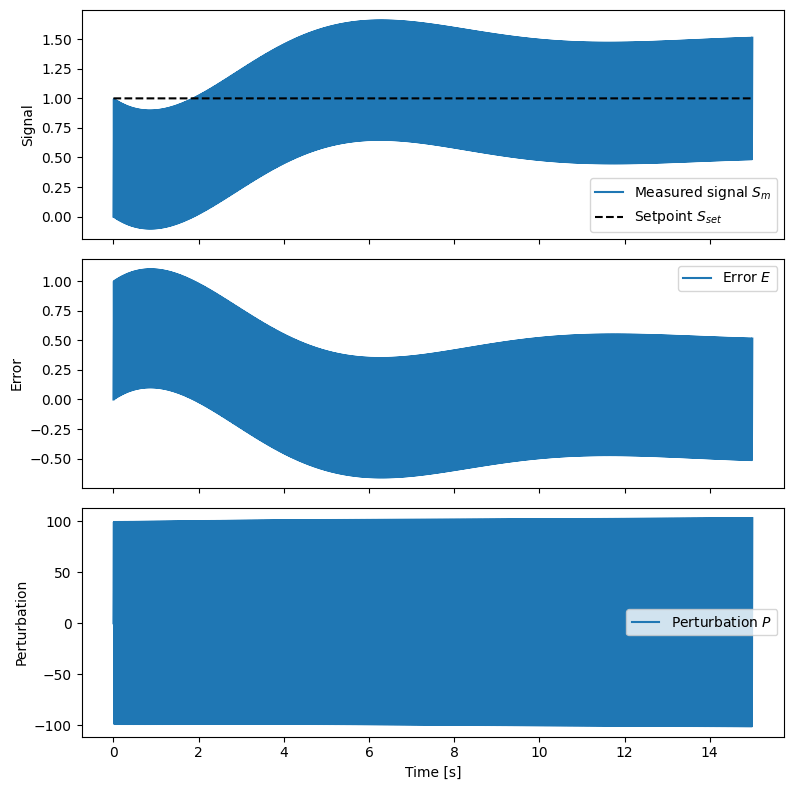

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parameters
# -----------------------------
dt = 0.01          # time step
T  = 15             # total time
N  = int(T/dt)

S_set = 1.0        # desired value (setpoint)
a_d   = 0.5     # derivative gain
a_i   = 0.8        # integral gain

# "Source" dynamics: dS_m/dt = -k*S_m + P
k = 1.0            # relaxation constant

# -----------------------------
# Storage arrays
# -----------------------------
t  = np.linspace(0, T, N)
S_m = np.zeros(N)
E   = np.zeros(N)
P   = np.zeros(N)
I   = 0.0          # integral of error
E_prev = 0.0       # previous error for derivative

# -----------------------------
# Simulation loop
# -----------------------------
for i in range(1, N):

    # Compute error
    E[i] = S_set - S_m[i-1]

    # Derivative of error
    dE = (E[i] - E_prev) / dt
    E_prev = E[i]

    # Integral of error
    I += E[i] * dt

    # Perturbation (controller output)
    P[i] = a_d * dE + a_i * I

    # Source dynamics (simple first-order system)
    S_m[i] = S_m[i-1] + dt * (-k * S_m[i-1] + P[i])

# -----------------------------
# Plot results
# -----------------------------
fig, ax = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

ax[0].plot(t, S_m, label="Measured signal $S_m$")
ax[0].plot(t, S_set*np.ones_like(t), 'k--', label="Setpoint $S_{set}$")
ax[0].set_ylabel("Signal")
ax[0].legend()

ax[1].plot(t, E, label="Error $E$")
ax[1].set_ylabel("Error")
ax[1].legend()

ax[2].plot(t, P, label="Perturbation $P$")
ax[2].set_ylabel("Perturbation")
ax[2].set_xlabel("Time [s]")
ax[2].legend()

plt.tight_layout()
plt.show()
